# Текстовая задача 

# Задание 2

### 2. Случайная величина имеет экспоненциальный закон распределения


\begin{equation*} 
p(x) =
\begin{cases} 
e^{-x}, & \text{если } x \geq 0, \\
0, & \text{если } x < 0.
\end{cases}
\end{equation*} 


#### a)
Сгенерируйте выборку объема \( n = 25 \).  
Определить по выборке:
- моду,  
- медиану,  
- размах,  
- оценку коэффициента асимметрии.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, special
import seaborn as sns
from math import comb

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

def p(x: float) -> float:
    """Плотность распределения"""
    return np.exp(-x) if x >= 0 else 0

def F(x: float) -> float:
    """Функция распределения"""
    return 1 - np.exp(-x) if x >= 0 else 0

def F_inv(y: float) -> float:
    """Обратная функция распределения"""
    return -np.log(1 - y)

N = 25
np.random.seed(42)

random_numbers = np.random.random(size=N)
sample = np.array([F_inv(y) for y in random_numbers])

ordered_sample = np.sort(sample)

print("=" * 60)
print("Исходная выборка:")
print(sample)
print("=" * 60)

def central_moment(k: int, data: list) -> float:
    """Вычисление выборочного центрального момента k-го порядка."""
    return np.mean([(x_i - np.mean(data))**k for x_i in data])

# Мода
unique, counts = np.unique(sample, return_counts=True)
if max(counts) > 1:
    mode_value = unique[np.argmax(counts)]
    mode_result = f"{mode_value:.4f} (повторяется {max(counts)} раз(а))"
else:
    mode_result = "Все значения уникальны (мода отсутствует)"

# Медиана
median_value = np.median(ordered_sample)

# Размах
range_value = np.ptp(ordered_sample)

# Коэффициент асимметрии
mu_2 = central_moment(2, sample)
mu_3 = central_moment(3, sample)
skewness = mu_3 / (mu_2 ** 1.5)


print("\nХарактеристики выборки:")
print(f"  Мода:           {mode_result}")
print(f"  Медиана:        {median_value:.6f}")
print(f"  Размах:         {range_value:.6f}")
print(f"  Коэф. асимметрии: {skewness:.6f}")

Исходная выборка:
[0.46926809 3.01012143 1.31674569 0.91294255 0.16962487 0.16959629
 0.05983877 2.01123086 0.91908215 1.23125006 0.02079931 3.50355748
 1.78642954 0.23868763 0.20067899 0.20261142 0.36275373 0.74392783
 0.56553707 0.34422299 0.94637087 0.15023453 0.34551551 0.45627722
 0.60893469]

Характеристики выборки:
  Мода:           Все значения уникальны (мода отсутствует)
  Медиана:        0.469268
  Размах:         3.482758
  Коэф. асимметрии: 1.699822


#### b)
Построить:
- эмпирическую функцию распределения,  
- гистограмму,  
- boxplot.

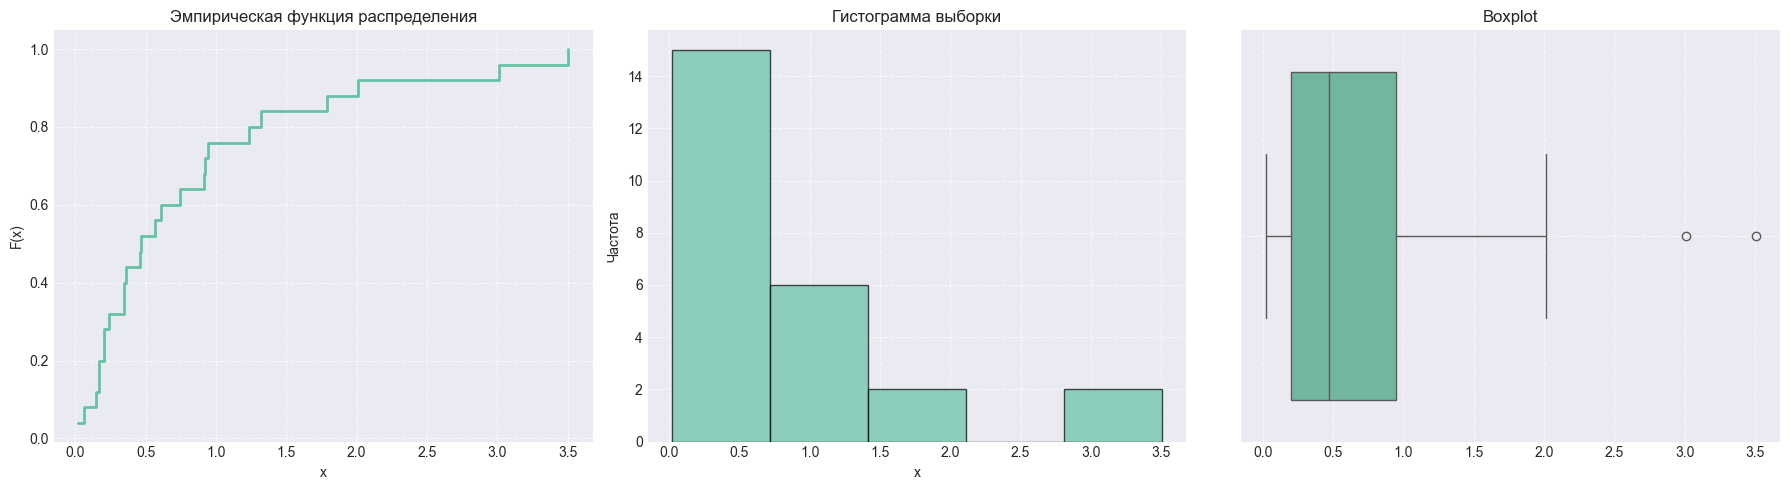

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Эмпирическая функция распределения
ax = axes[0]
ax.set_title("Эмпирическая функция распределения")
ax.set_xlabel("x")
ax.set_ylabel("F(x)")

# Строим ступенчатый график
ax.step(ordered_sample,
        np.arange(1, N + 1) / N,
        where='post',
        linewidth=2)
ax.grid(True, linestyle='--', alpha=0.7)


# Гистограмма
ax = axes[1]
ax.set_title("Гистограмма выборки")
ax.set_xlabel("x")
ax.set_ylabel("Частота")

bins = int(1 + np.log2(N))
ax.hist(sample, bins=bins, edgecolor='black', alpha=0.7, density=False)
ax.grid(True, linestyle='--', alpha=0.7)


# Boxplot
ax = axes[2]
ax.set_title("Boxplot")
sns.boxplot(x=sample, ax=ax)
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


#### c)
Сравнить оценку плотности распределения среднего арифметического элементов выборки, полученную с помощью центральной предельной теоремы (ЦПТ), с бутстраповой оценкой этой плотности.

### Математическое обоснование для ЦПТ

Для экспоненциального распределения с плотностью 
$$
p(x) = e^{-x}, x \geq 0\:
$$
$$
\mathbb{M}[\xi] = \int_{0}^{\infty} x e^{-x} \, dx = 1
$$

$$
\mathbb{M}[\xi^2] = \int_{0}^{\infty} x^2 e^{-x} \, dx = 2
$$

$$
\mathbb{D}[\xi] = \mathbb{M}[\xi^2] - (\mathbb{M}[\xi])^2 = 2 - 1^2 = 1
$$

##### ЦПТ:

По **Центральной предельной теореме (ЦПТ)**, распределение выборочного среднего 
$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} \xi_i
$$ 
при больших n стремится к нормальному:

$$
\frac{\bar{x} - \mathbb{M}[\xi]}{\sqrt{\mathbb{D}[\xi]}} \cdot \sqrt{n} \xrightarrow[n\to\infty]{d} \mathcal{N}(0, 1)
$$

Для нашей выборки \(n = 25\):

$$
\frac{\bar{x} - 1}{\sqrt{1}} \cdot \sqrt{25} \longrightarrow \mathcal{N}(0, 1)
$$

$$
\bar{x} \longrightarrow \mathcal{N}\left(1, \frac{1}{25}\right)
$$

где $$\frac{1}{25} = 0.04$$ — это дисперсия, а стандартное отклонение равно $$\sigma = \sqrt{0.04} = 0.2$$.

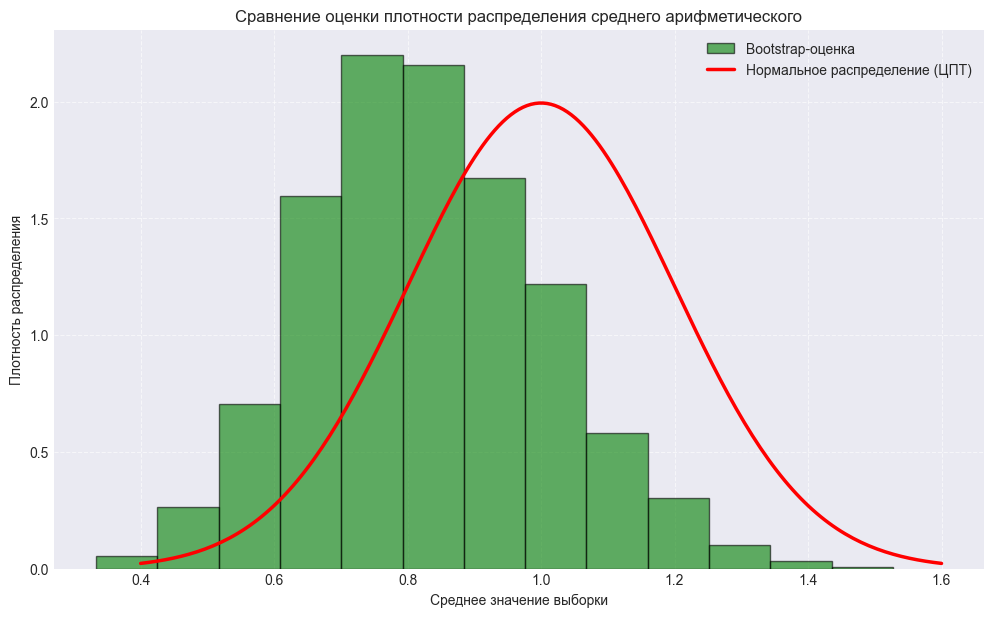

In [8]:
mu_theory = 1
sigma_theory = np.sqrt(1 / N)

B = 5000
bootstrap_means = []

for _ in range(B):
    bootstrap_sample = np.random.choice(sample, size=N, replace=True)
    bootstrap_means.append(np.mean(bootstrap_sample))

bootstrap_means = np.array(bootstrap_means)

plt.figure(figsize=(12, 7))

# Гистограмма bootstrap-оценки
plt.hist(bootstrap_means, bins=int(1 + np.log2(B)), density=True,
         alpha=0.6, color='green', edgecolor='black', label='Bootstrap-оценка')

# Теоретическая кривая по ЦПТ
x_theory = np.linspace(mu_theory - 3*sigma_theory, mu_theory + 3*sigma_theory, 200)
y_theory = stats.norm.pdf(x_theory, loc=mu_theory, scale=sigma_theory)
plt.plot(x_theory, y_theory, 'r-', linewidth=2.5, label='Нормальное распределение (ЦПТ)')

plt.title('Сравнение оценки плотности распределения среднего арифметического')
plt.xlabel('Среднее значение выборки')
plt.ylabel('Плотность распределения')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### d)
Найти бутстраповскую оценку плотности распределения коэффициента асимметрии и оценить вероятность того, что коэффициент асимметрии будет меньше 1.

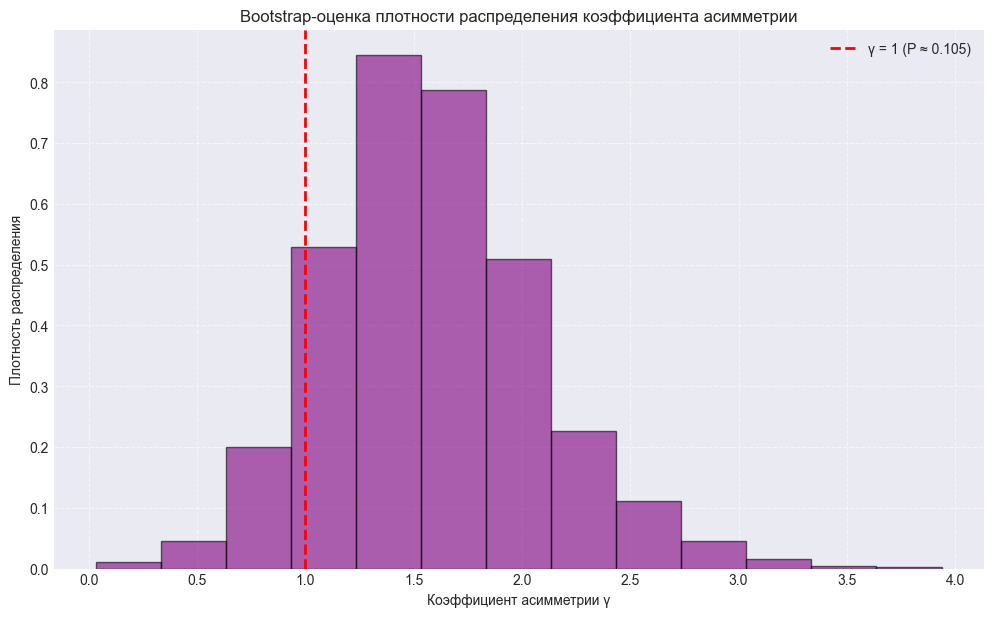


Оценка вероятности P(γ < 1) = 0.1054


In [9]:
bootstrap_skewness = []

for _ in range(B):
    bootstrap_sample = np.random.choice(sample, size=N, replace=True)
    m2 = central_moment(2, bootstrap_sample)
    m3 = central_moment(3, bootstrap_sample)
    skew = m3 / (m2 ** 1.5) if m2 > 1e-10 else 0
    bootstrap_skewness.append(skew)

bootstrap_skewness = np.array(bootstrap_skewness)

prob_skew_less_than_1 = np.mean(bootstrap_skewness < 1)

plt.figure(figsize=(12, 7))
plt.hist(bootstrap_skewness, bins=int(1 + np.log2(B)), density=True,
         alpha=0.6, color='purple', edgecolor='black')
plt.title('Bootstrap-оценка плотности распределения коэффициента асимметрии')
plt.xlabel('Коэффициент асимметрии γ')
plt.ylabel('Плотность распределения')
plt.axvline(x=1, color='red', linestyle='--', linewidth=2, label=f'γ = 1 (P ≈ {prob_skew_less_than_1:.3f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"\nОценка вероятности P(γ < 1) = {prob_skew_less_than_1:.4f}")


#### e)
Сравнить плотность распределения медианы выборки с бутстраповой оценкой этой плотности.

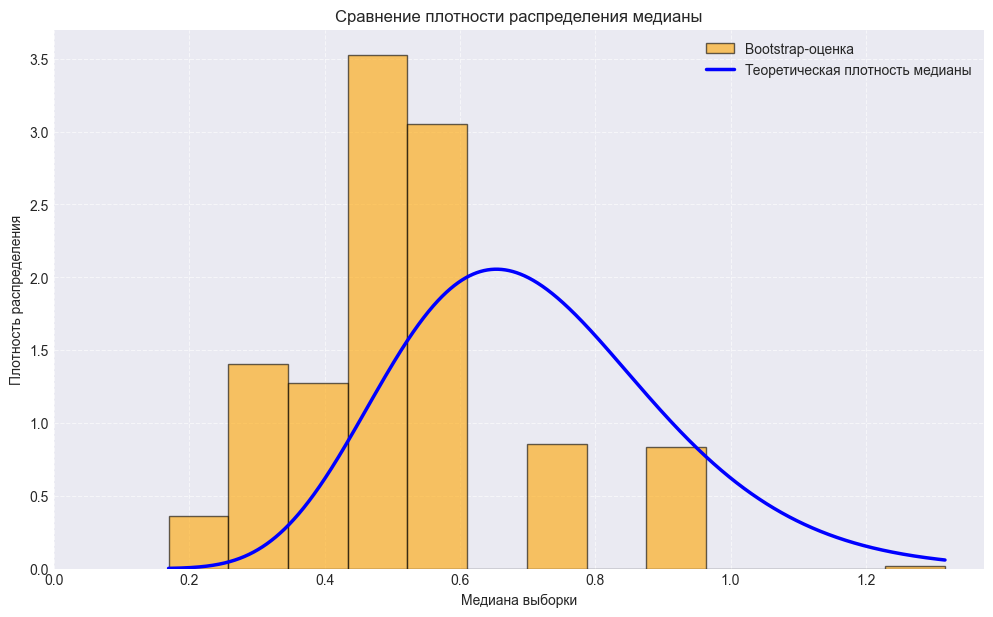

In [10]:
def median_pdf(x: float) -> float:
    """
    Теоретическая плотность распределения медианы для выборки
    из экспоненциального распределения.
    """
    if x < 0:
        return 0
    k = N // 2 + 1
    coeff = N * special.comb(N - 1, k - 1)
    term1 = (F(x)) ** (k - 1)
    term2 = (1 - F(x)) ** (N - k)
    return coeff * p(x) * term1 * term2

# Bootstrap для медианы
bootstrap_medians = []
for _ in range(B):
    bootstrap_sample = np.random.choice(sample, size=N, replace=True)
    bootstrap_medians.append(np.median(bootstrap_sample))
bootstrap_medians = np.array(bootstrap_medians)

x_vals = np.linspace(min(bootstrap_medians), max(bootstrap_medians), B)
y_vals = [median_pdf(xi) for xi in x_vals]

plt.figure(figsize=(12, 7))
plt.hist(bootstrap_medians, bins=int(1 + np.log2(B)), density=True,
         alpha=0.6, color='orange', edgecolor='black', label='Bootstrap-оценка')
plt.plot(x_vals, y_vals, 'b-', linewidth=2.5, label='Теоретическая плотность медианы')

plt.title('Сравнение плотности распределения медианы')
plt.xlabel('Медиана выборки')
plt.ylabel('Плотность распределения')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, None)
plt.show()
